# Identifying Trends Over Time Using Line Plots

**Milestone: Identifying Trends Over Time Using Line Plots**  
**Project: Trivin Insight Engine**  
**Date: March 2026**

---

## Learning Objectives

By completing this notebook, you will be able to:

1. ✅ Understand what time-series data represents
2. ✅ Create line plots for time-based data
3. ✅ Identify upward, downward, and stable patterns
4. ✅ Spot spikes, drops, and short periods of volatility
5. ✅ Interpret trends over time without turning EDA into forecasting

---

## Why This Matters

Time adds context that static analysis cannot provide. A summary statistic can tell you an average, but only a line plot can show whether the metric is drifting, stable, or changing suddenly across the timeline.

Common beginner issues include:

- Treating time like unordered data
- Missing long-term trends because only snapshots are reviewed
- Overreacting to one sudden change
- Confusing noise with a meaningful trend

This notebook focuses on descriptive trend analysis only. No forecasting or modeling is required.

## Setup: Import Libraries and Load Data

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

csv_path = project_root / 'data' / 'raw' / 'employee_survey_2026_Q1.csv'
figure_dir = project_root / 'outputs' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(csv_path, parse_dates=['survey_date'])
df = df.sort_values('survey_date').reset_index(drop=True)

print(f'Dataset loaded from: {csv_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nColumns:')
print(df.columns.tolist())
print('\nFirst 5 rows after sorting by survey_date:')
df[['survey_date', 'department', 'satisfaction_score']].head()

Dataset loaded from: c:\Users\USER\OneDrive\Desktop\Data-science\S86_Trivin_Insight_Engine_Sprint3\data\raw\employee_survey_2026_Q1.csv
Shape: 30 rows x 9 columns

Columns:
['employee_id', 'department', 'survey_date', 'satisfaction_score', 'work_life_balance', 'management_support', 'career_growth', 'team_collaboration', 'response_text']

First 5 rows after sorting by survey_date:


,survey_date,department,satisfaction_score
0,2026-01-15,Engineering,7
1,2026-01-16,Marketing,9
2,2026-01-17,Sales,4
3,2026-01-18,Engineering,8
4,2026-01-19,HR,6


---

## Part 1: Understanding Time-Based Data

A time-based column represents when an observation happened. In this dataset, `survey_date` lets us observe how employee satisfaction changes across the period covered by the survey.

Before plotting, we need to answer two basic questions:

1. Is the column stored as a real date?
2. Are the rows ordered correctly by time?

Correct ordering is essential because line plots connect points in sequence.

In [3]:
print('Time column dtype:', df['survey_date'].dtype)
print('Date range:', df['survey_date'].min().date(), 'to', df['survey_date'].max().date())
print('Unique dates:', df['survey_date'].nunique())

intervals = df['survey_date'].drop_duplicates().diff().dropna().dt.days
print('\nDays between observations:')
print(intervals.value_counts().sort_index())

if intervals.nunique() == 1:
    print('\nThe timeline uses regular intervals.')
else:
    print('\nThe timeline is mostly regular, but there is at least one gap. Sorting still matters.')

Time column dtype: datetime64[ns]
Date range: 2026-01-15 to 2026-02-14
Unique dates: 30

Days between observations:
survey_date
1    28
2     1
Name: count, dtype: int64

The timeline is mostly regular, but there is at least one gap. Sorting still matters.


## Part 2: Creating a Basic Line Plot

We will use `survey_date` on the x-axis and `satisfaction_score` on the y-axis.

Because there is one survey response per day in this dataset, the daily average is easy to interpret. For larger datasets, daily aggregation is still a good habit because multiple responses can occur on the same date.

In [4]:
daily = df.groupby('survey_date', as_index=False)['satisfaction_score'].mean()
daily['rolling_5_day_avg'] = daily['satisfaction_score'].rolling(window=5, min_periods=1).mean()
daily['daily_change'] = daily['satisfaction_score'].diff()
daily.head()

,survey_date,satisfaction_score,rolling_5_day_avg,daily_change
0,2026-01-15,7.0,7.000000,NaN
1,2026-01-16,9.0,8.000000,2.0
2,2026-01-17,4.0,6.666667,-5.0
3,2026-01-18,8.0,7.000000,4.0
4,2026-01-19,6.0,6.800000,-2.0


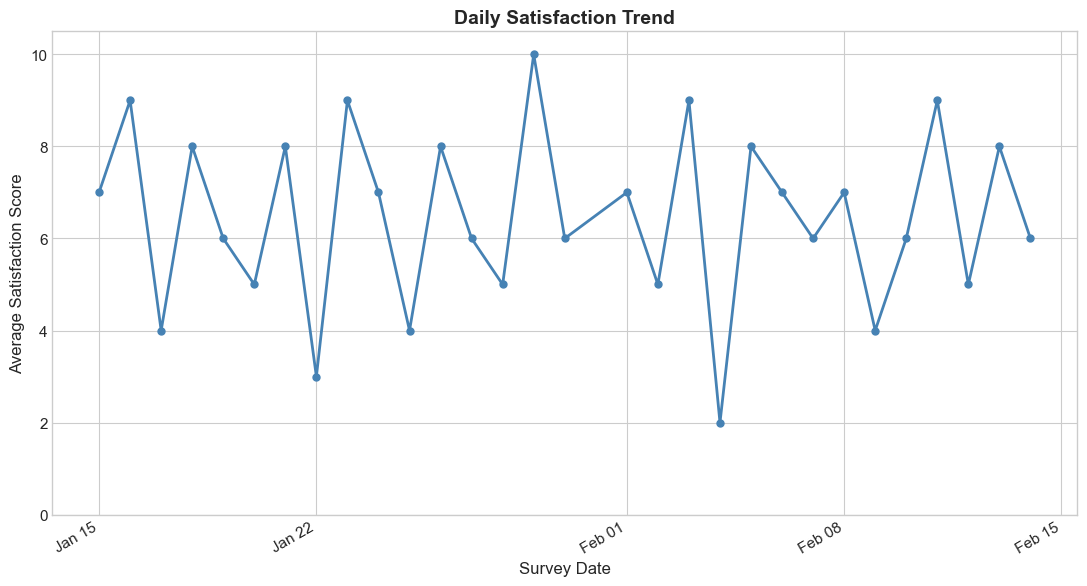

Saved: outputs/figures/notebook_daily_satisfaction_trend.png


In [5]:
fig, ax = plt.subplots()
ax.plot(daily['survey_date'], daily['satisfaction_score'], color='steelblue', linewidth=2, marker='o', markersize=5)
ax.set_title('Daily Satisfaction Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Survey Date', fontsize=12)
ax.set_ylabel('Average Satisfaction Score', fontsize=12)
ax.set_ylim(0, 10.5)
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(figure_dir / 'notebook_daily_satisfaction_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: outputs/figures/notebook_daily_satisfaction_trend.png')

### Interpretation Questions

Look at the plot above and answer:

1. Does the trend look mostly upward, downward, or mixed?
2. Are there any sharp rises or sharp drops?
3. Does the line stay within a narrow range or move a lot?
4. Would you trust a conclusion based on one point alone? Why not?

## Part 3: Distinguishing Trend from Noise

Raw daily values can move up and down quickly. A rolling average helps smooth short-term fluctuation so the broader direction is easier to see.

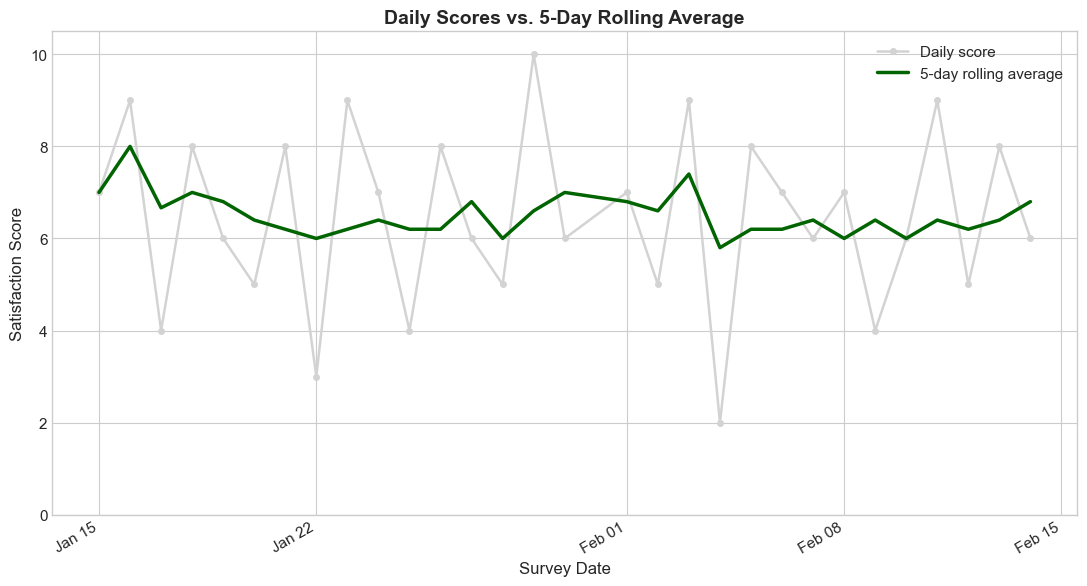

In [6]:
fig, ax = plt.subplots()
ax.plot(daily['survey_date'], daily['satisfaction_score'], color='lightgray', linewidth=1.8, marker='o', markersize=4, label='Daily score')
ax.plot(daily['survey_date'], daily['rolling_5_day_avg'], color='darkgreen', linewidth=2.5, label='5-day rolling average')
ax.set_title('Daily Scores vs. 5-Day Rolling Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Survey Date', fontsize=12)
ax.set_ylabel('Satisfaction Score', fontsize=12)
ax.set_ylim(0, 10.5)
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Part 4: Looking at a Higher-Level Trend

Resampling to weekly averages is another way to reduce noise. It makes it easier to discuss the broader direction across the whole period.

In [7]:
weekly = df.set_index('survey_date').resample('W')['satisfaction_score'].mean().reset_index()
weekly

,survey_date,satisfaction_score
0,2026-01-18,7.000000
1,2026-01-25,6.000000
2,2026-02-01,7.000000
3,2026-02-08,6.285714
4,2026-02-15,6.333333


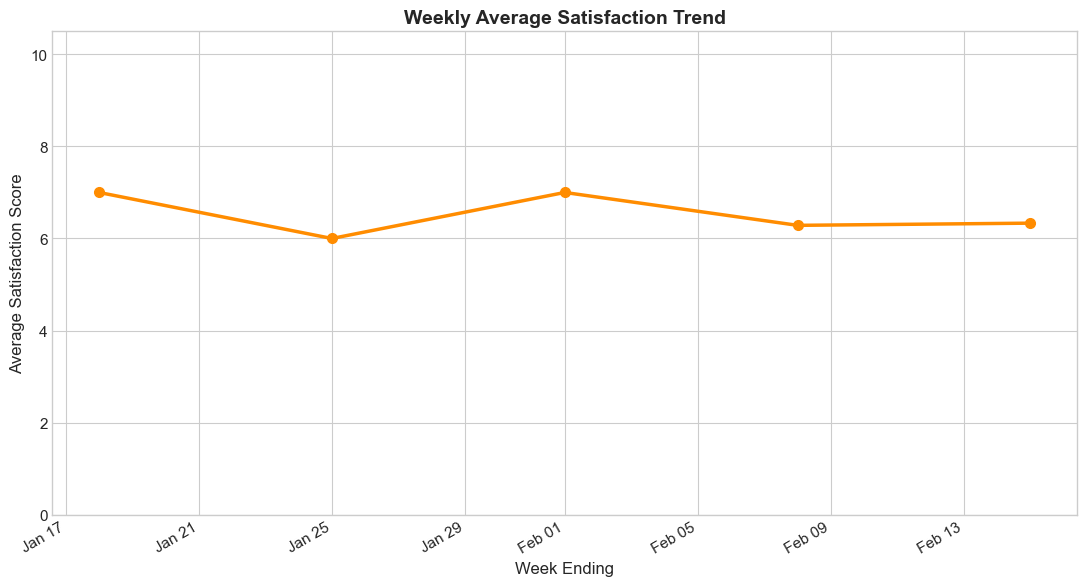

In [8]:
fig, ax = plt.subplots()
ax.plot(weekly['survey_date'], weekly['satisfaction_score'], color='darkorange', linewidth=2.5, marker='o', markersize=7)
ax.set_title('Weekly Average Satisfaction Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Week Ending', fontsize=12)
ax.set_ylabel('Average Satisfaction Score', fontsize=12)
ax.set_ylim(0, 10.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Part 5: Spotting Spikes, Drops, and Sudden Shifts

A line plot is useful for identifying unusual changes. That does not mean we know the cause. It only means the chart helps us notice where a question should be investigated.

In [9]:
largest_drop = daily.loc[daily['daily_change'].idxmin(), ['survey_date', 'daily_change', 'satisfaction_score']]
largest_rise = daily.loc[daily['daily_change'].idxmax(), ['survey_date', 'daily_change', 'satisfaction_score']]

print('Largest one-day drop:')
print(largest_drop)

print('\nLargest one-day rise:')
print(largest_rise)

Largest one-day drop:
survey_date           2026-02-04 00:00:00
daily_change                         -7.0
satisfaction_score                    2.0
Name: 19, dtype: object

Largest one-day rise:
survey_date           2026-01-23 00:00:00
daily_change                          6.0
satisfaction_score                    9.0
Name: 8, dtype: object


## Part 6: Comparing a Few Lines Without Clutter

Line plots can compare groups over time, but too many lines become hard to read. Here we limit the chart to three departments with clearly different patterns.

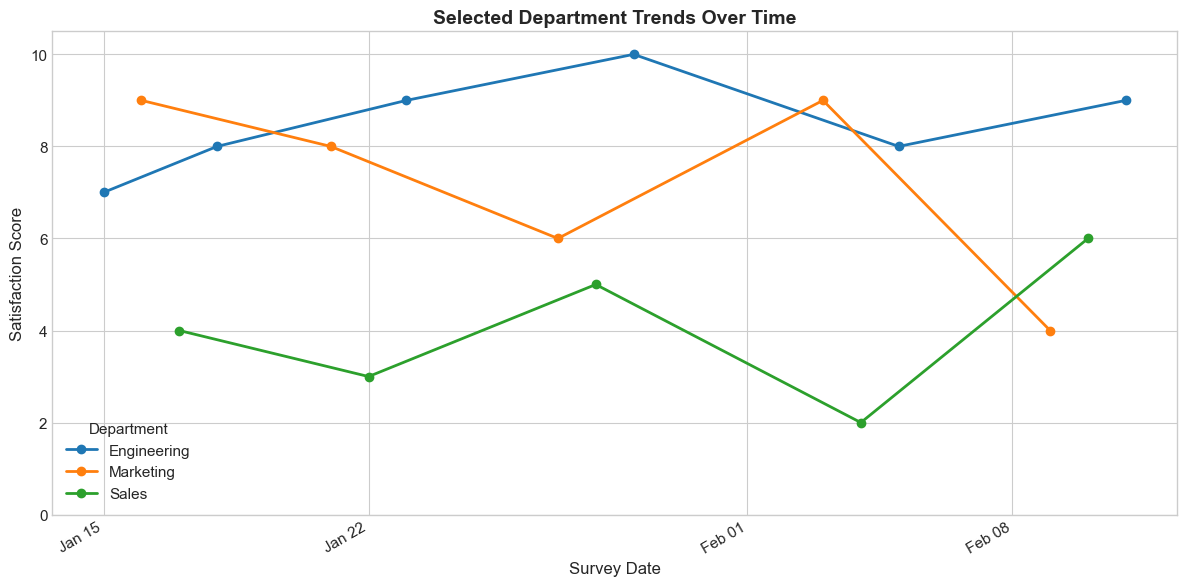

In [10]:
selected_departments = ['Engineering', 'Marketing', 'Sales']
selected = df[df['department'].isin(selected_departments)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
for department in selected_departments:
    subset = selected[selected['department'] == department]
    ax.plot(subset['survey_date'], subset['satisfaction_score'], marker='o', linewidth=2, label=department)

ax.set_title('Selected Department Trends Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Survey Date', fontsize=12)
ax.set_ylabel('Satisfaction Score', fontsize=12)
ax.set_ylim(0, 10.5)
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Department')
plt.tight_layout()
plt.show()

---

## Practice Exercises

1. Create a line plot for `work_life_balance` over `survey_date`.
2. Compare the raw daily line with a rolling average for `management_support`.
3. Select a different set of departments and create a readable comparison line plot.
4. Write a 3-sentence interpretation describing one overall trend and one anomaly.

## Key Takeaways

- Always sort by the time column before plotting
- Use line plots when order across time matters
- Look for broad movement, not just one point
- Use rolling averages or weekly aggregation to reduce noise
- Limit the number of lines to keep the chart readable
- Treat spikes and drops as signals for investigation, not instant conclusions

**Milestone complete:** You can now visualize and interpret trends over time using line plots as part of EDA.